In [1]:
import pandas as pd
import sys
from pathlib import Path

from sklearn.pipeline import Pipeline

sys.path.append(str(Path("../src").resolve()))

from exoplanet_detector.features.feature_selection import (
    CONSTANT_VALUE_DROP_COLUMNS,
    CORRELATION_DROP_COLUMNS,
    ANALYSIS_DROP_COLUMNS,
    LEFT_SKEWED_COLUMNS,
    RIGHT_SKEWED_COLUMNS,
    EXPLORATORY_RIGHT_SKEWED_COLUMNS,
    FINAL_FEATURE_COLUMNS,
    PHYSICAL_INTERVALS,
)

from exoplanet_detector.features.custom_transformers import (
    ColumnDropper,
    IqrClipper,
    LeftSkewReflectLogTransformer,
    PhysicalOutlierScreener,
    RightSkewLogTransformer,
)
from exoplanet_detector.features.preprocessing import feature_summary
from exoplanet_detector.visualization.plots import plot_corr_heatmap, plot_feature_histograms

pd.set_option('display.max_columns', None) 
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None) 

We will inspect the train set of `koi` to find correlations, outliers and missing values.

In [2]:
df = pd.read_csv("../data/processed/KOI_train_set.csv")

In [3]:
df.head()

,group_id,label,orbital_period_days,eccentricity,impact_parameter,transit_duration_hours,transit_depth,radius_ratio_rp_rs,inclination_deg,a_over_rs,planet_radius_rearth,semi_major_axis_au,equilibrium_temp_k,insolation_earth,stellar_teff_k,stellar_logg_cgs,stellar_metallicity_dex,stellar_radius_rsun,stellar_mass_msun
0,10797460,1,9.488036,0.0,0.146,2.9575,615.8,0.022344,89.66,24.81,2.26,0.0853,793.0,93.59,5455.0,4.467,0.14,0.927,0.919
1,10797460,1,54.418383,0.0,0.586,4.5070,874.8,0.027954,89.57,77.90,2.83,0.2734,443.0,9.11,5455.0,4.467,0.14,0.927,0.919
2,10854555,1,2.525592,0.0,0.701,1.6545,603.3,0.024064,85.41,8.75,2.75,0.0374,1406.0,926.16,6031.0,4.438,0.07,1.046,1.095
3,10872983,1,11.094321,0.0,0.538,4.5945,1517.5,0.036779,88.11,16.36,3.90,0.0992,835.0,114.81,6046.0,4.486,-0.08,0.972,1.053
4,10872983,1,4.134435,0.0,0.762,3.1402,686.0,0.026133,83.72,6.96,2.77,0.0514,1160.0,427.65,6046.0,4.486,-0.08,0.972,1.053


We will plot the histogram for each feature to inspect the distribution of data.

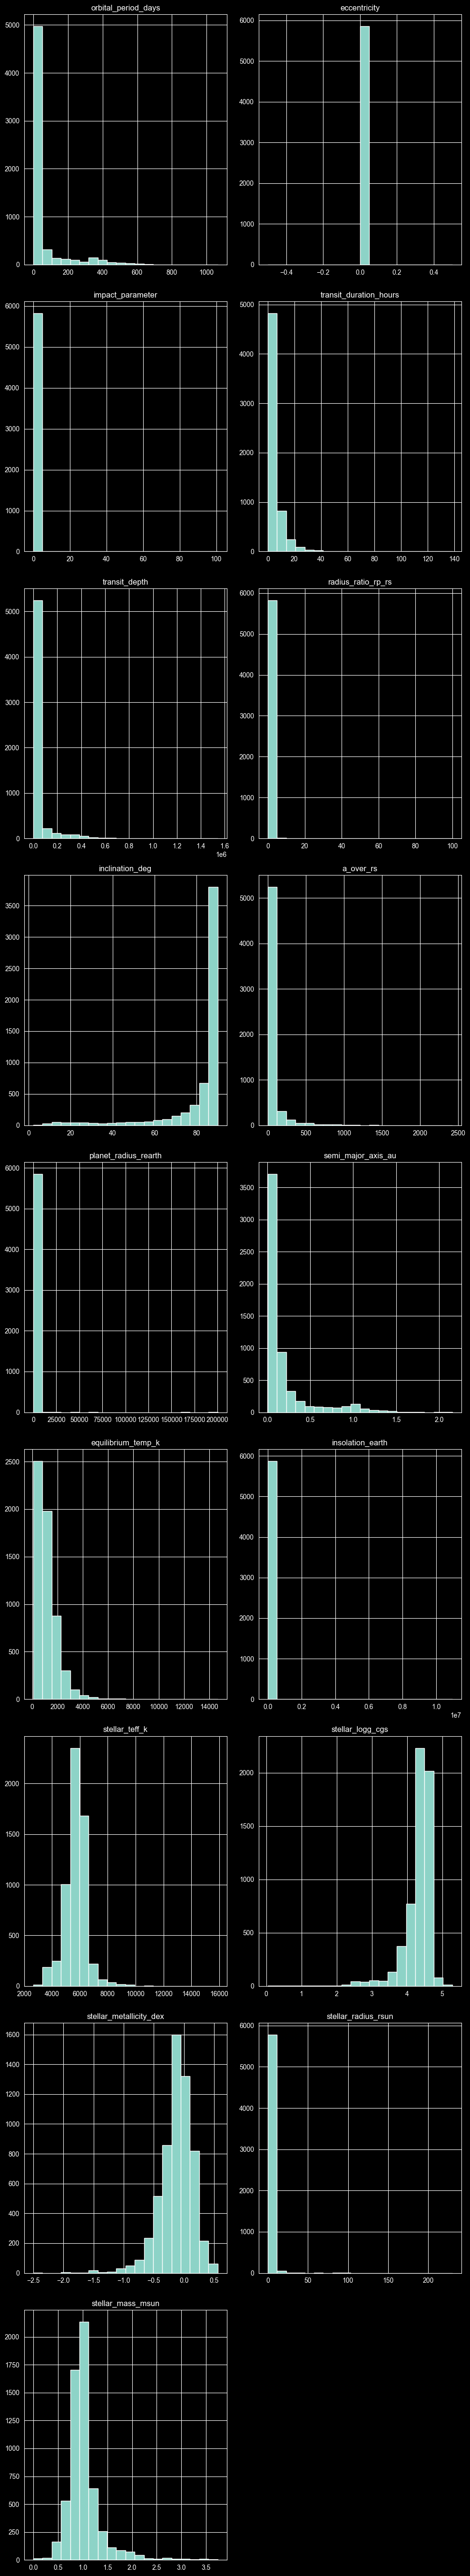

In [4]:
df_features = df.drop(["group_id", "label"], axis=1)
plot_feature_histograms(df_features)

The majority of features seems rather skewed. We also see some features to have single values. These shall be removed.  
We will use a custom `feature_summary` method to display a table that will allow us to inspect the distribution and the number of unique values per feature more precisely.

In [5]:
summary = feature_summary(df_features)
display(summary)

,feature,n,missing_rate,n_unique,top_value_frac,p01,p25,median,p75,p99,IQR
3,transit_duration_hours,6068,0.000000,5455,0.000659,0.857880,2.485750,3.845450,6.249250,32.219900,3.763500
0,orbital_period_days,6068,0.000000,6068,0.000165,0.523152,2.232279,8.026400,29.908247,528.239728,27.675968
11,insolation_earth,6068,0.029829,5300,0.001529,0.390000,27.405000,180.550000,1160.300000,76090.567200,1132.895000
1,eccentricity,6068,0.035267,1,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
16,stellar_mass_msun,6068,0.035267,1251,0.016057,0.453060,0.841000,0.973000,1.097000,2.442410,0.256000
13,stellar_logg_cgs,6068,0.035267,1305,0.015716,2.480830,4.221000,4.438000,4.545000,4.810000,0.324000
15,stellar_radius_rsun,6068,0.035267,1830,0.014520,0.443000,0.828000,0.998000,1.335500,13.822590,0.507500
12,stellar_teff_k,6068,0.035267,2077,0.014178,3624.120000,5311.000000,5771.000000,6109.750000,8205.110000,798.750000
2,impact_parameter,6068,0.035267,1811,0.004612,0.003406,0.223000,0.589000,0.917000,1.827686,0.694000
8,planet_radius_rearth,6068,0.035267,2349,0.004100,0.520000,1.500000,2.610000,24.140000,379.290800,22.640000


No more than 3.5% of values in each column is missing, which is good. Furthermore, in all columns except for `eccentricity` the number of unique values is high. `eccentricity` will therefore be dropped.
Several columns seem to be highly skewed, which has already been visible on histograms - logarithmic transformation will be applied on them.

In [6]:
right_skewed_cols = list(EXPLORATORY_RIGHT_SKEWED_COLUMNS)
left_skewed_cols = list(LEFT_SKEWED_COLUMNS)
drop_cols = list(CONSTANT_VALUE_DROP_COLUMNS)

In [7]:
eps = 1e-6
reflection_max = {"inclination_deg": 90.0 + eps}

train_preprocessing_pipeline = Pipeline(
    steps=[
        ("drop_constants", ColumnDropper(drop_cols)),
        ("physical_screen", PhysicalOutlierScreener(intervals=PHYSICAL_INTERVALS)),
        ("right_log", RightSkewLogTransformer(right_skewed_cols)),
        (
            "left_log",
            LeftSkewReflectLogTransformer(
                columns=left_skewed_cols,
                reflection_max=reflection_max,
                eps=eps,
            ),
        ),
        ("iqr_clip", IqrClipper()),
    ]
)

df_features_transformed = train_preprocessing_pipeline.fit_transform(df_features)

fitted_reflection_max = train_preprocessing_pipeline.named_steps["left_log"].reflection_max_
physical_outlier_summary = train_preprocessing_pipeline.named_steps["physical_screen"].last_summary_
iqr_fences = train_preprocessing_pipeline.named_steps["iqr_clip"].fences_
iqr_outlier_summary = train_preprocessing_pipeline.named_steps["iqr_clip"].fit_summary_

We will store the `fitted_reflection_max` variable to apply it also to a test part and avoid leakage.

In [8]:
fitted_reflection_max

{'inclination_deg': 90.000001}

Now we will inspect outliers. First, let's check for physical outliers. If found, they will be set to `Nan` and later imputed with the remaining missing values.

In [9]:
display(physical_outlier_summary)

,feature,lower,upper,out_of_range_n,out_of_range_pct
1,impact_parameter,0.0,2.0,51,0.008405
0,orbital_period_days,0.0,NaN,0,0.000000
2,transit_duration_hours,0.0,NaN,0,0.000000
3,transit_depth,0.0,NaN,0,0.000000
4,radius_ratio_rp_rs,0.0,NaN,0,0.000000
5,inclination_deg,0.0,90.0,0,0.000000
6,a_over_rs,0.0,NaN,0,0.000000
7,planet_radius_rearth,0.0,NaN,0,0.000000
8,semi_major_axis_au,0.0,NaN,0,0.000000
9,equilibrium_temp_k,0.0,NaN,0,0.000000


For statistical outliers, we will compute per-feature IQR fences and clip outlier values to the train fences. We will later reuse those fences on the test set and on `K2P`.

In [10]:
display(iqr_outlier_summary)

,feature,q1,q3,iqr,lower_fence,upper_fence,outlier_n,outlier_pct
8,semi_major_axis_au,0.032588,0.161609,0.129020,-0.160942,0.355139,718,0.118326
14,stellar_radius_rsun,0.828000,1.335500,0.507500,0.066750,2.096750,618,0.101846
4,radius_ratio_rp_rs,0.013219,0.196019,0.182801,-0.260982,0.470220,558,0.091958
3,transit_depth,5.211806,7.712801,2.500996,1.460312,11.464295,548,0.090310
15,stellar_mass_msun,0.841000,1.097000,0.256000,0.457000,1.481000,461,0.075972
12,stellar_logg_cgs,4.221000,4.545000,0.324000,3.735000,5.031000,396,0.065260
11,stellar_teff_k,5311.000000,6109.750000,798.750000,4112.875000,7307.875000,367,0.060481
2,transit_duration_hours,1.248683,1.980898,0.732215,0.150361,3.079220,181,0.029829
13,stellar_metallicity_dex,-0.260000,0.070000,0.330000,-0.755000,0.565000,159,0.026203
6,a_over_rs,1.671943,3.586161,1.914218,-1.199385,6.457489,75,0.012360


Now let's plot a correlation heatmap of our features, also using a custom method.

In [11]:
corr = df_features_transformed.corr(method="spearman")

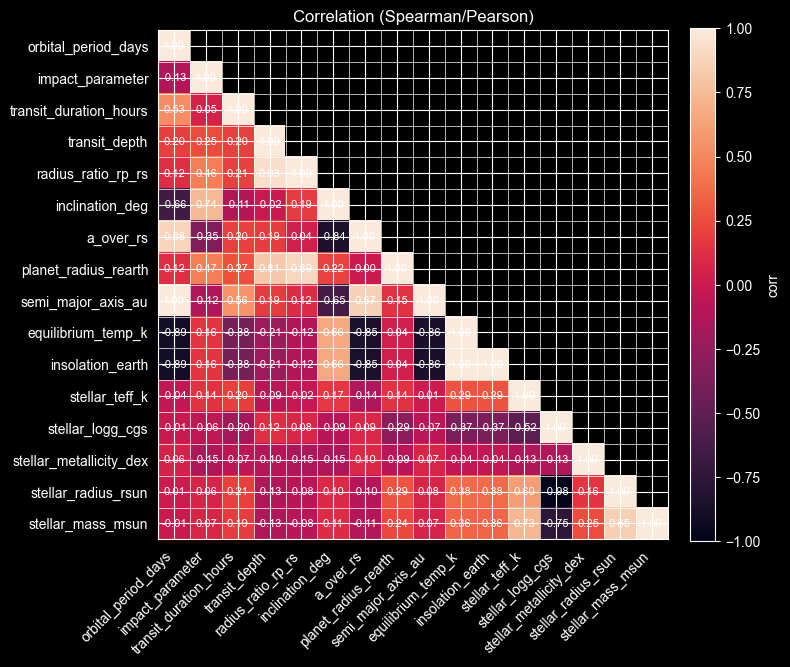

In [12]:
plot_corr_heatmap(corr, mask_upper=True, annotate=True)

We can notice 4 pairs of features with absolute correlation above 0.90 - `semi_major_axis_au` and `orbital_period_days`, `insolation_earth` and `equilibrium_temp_k`, `stellar_radius_rsun` and `stellar_log_cgs`, and `radius_ratio_rp_rs` and `transit_depth`. The third of these comes directly from the formula for stellar gravity, which is obtained by dividing radius by mass squared. For this reason, also stellar radius and mass features will be dropped.

In [13]:
drop_cols_2 = list(CORRELATION_DROP_COLUMNS)

In [14]:
df_features_transformed2 = df_features_transformed.drop(drop_cols_2, axis=1)
corr2 = df_features_transformed2.corr(method="spearman")

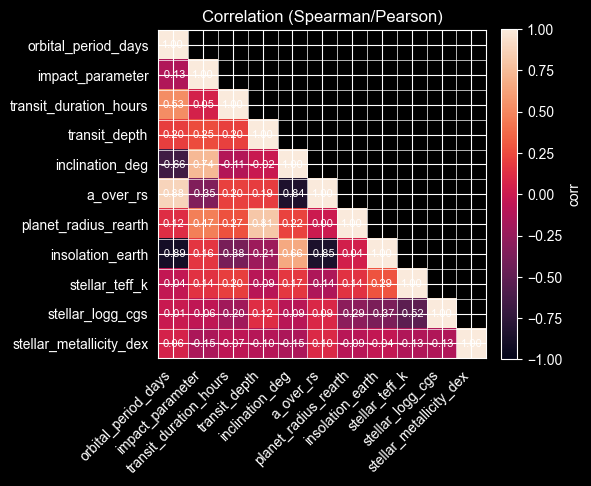

In [15]:
plot_corr_heatmap(corr2, annotate=True)

We can conduct a similar analysis for a KOI test set and a K2P set 

In [16]:
koi_test = pd.read_csv("../data/processed/KOI_test_set.csv")
k2p = pd.read_csv("../data/processed/K2P_set.csv")

In [17]:
drop_analysis_cols = list(ANALYSIS_DROP_COLUMNS)
right_skewed = list(RIGHT_SKEWED_COLUMNS)
left_skewed = list(LEFT_SKEWED_COLUMNS)

In [18]:
reflection_max_eval = fitted_reflection_max

koi_test_features = koi_test.drop(["group_id", "label"], axis=1)
k2p_features = k2p.drop(["group_id", "label"], axis=1)

eval_preprocessing_pipeline = Pipeline(
    steps=[
        ("drop_analysis", ColumnDropper(drop_analysis_cols)),
        ("physical_screen", PhysicalOutlierScreener(intervals=PHYSICAL_INTERVALS)),
        ("right_log", RightSkewLogTransformer(right_skewed)),
        (
            "left_log",
            LeftSkewReflectLogTransformer(
                columns=left_skewed,
                reflection_max=reflection_max_eval,
                eps=eps,
            ),
        ),
        ("iqr_clip", IqrClipper(fences=iqr_fences)),
    ]
)

eval_preprocessing_pipeline.fit(koi_test_features)

koi_test = eval_preprocessing_pipeline.transform(koi_test_features)
physical_outlier_summary_koi = eval_preprocessing_pipeline.named_steps["physical_screen"].last_summary_

k2p = eval_preprocessing_pipeline.transform(k2p_features)
physical_outlier_summary_k2p = eval_preprocessing_pipeline.named_steps["physical_screen"].last_summary_

koi_test = koi_test.loc[:, FINAL_FEATURE_COLUMNS].copy()
k2p = k2p.loc[:, FINAL_FEATURE_COLUMNS].copy()

In [19]:
summary_koi = feature_summary(koi_test)
summary_k2p = feature_summary(k2p)

In [20]:
display(summary_koi)

,feature,n,missing_rate,n_unique,top_value_frac,p01,p25,median,p75,p99,IQR
2,transit_duration_hours,1517,0.000000,1433,0.029664,6.098069e-01,1.237011,1.559197,1.997811,3.079220,0.760800
0,orbital_period_days,1517,0.000000,1517,0.000659,4.260925e-01,1.189709,2.218491,3.516222,6.196843,2.326513
7,insolation_earth,1517,0.025049,1431,0.004733,3.058611e-01,3.290823,5.197336,7.031549,11.660207,3.740726
3,transit_depth,1517,0.029664,1266,0.095109,3.195100e+00,5.224939,6.232936,8.006884,11.464295,2.781945
9,stellar_logg_cgs,1517,0.029664,590,0.072690,3.735000e+00,4.192500,4.436000,4.538000,4.791580,0.345500
4,inclination_deg,1517,0.029664,784,0.058424,9.999995e-07,0.298247,1.059524,2.184364,4.355841,1.886118
8,stellar_teff_k,1517,0.029664,828,0.039402,4.112875e+03,5334.000000,5780.000000,6136.000000,7307.875000,802.000000
5,a_over_rs,1517,0.029664,1320,0.014266,7.533345e-01,1.697928,2.689885,3.629650,6.457489,1.931721
6,planet_radius_rearth,1517,0.029664,861,0.006114,4.298932e-01,0.923265,1.302913,3.257799,6.077307,2.334535
10,stellar_metallicity_dex,1517,0.030982,65,0.047619,-7.550000e-01,-0.280000,-0.100000,0.060000,0.386200,0.340000


In [21]:
display(summary_k2p)

,feature,n,missing_rate,n_unique,top_value_frac,p01,p25,median,p75,p99,IQR
0,orbital_period_days,830,0.007229,821,0.004854,0.408518,1.177278,1.949489,2.602922,5.472081,1.425643
8,stellar_teff_k,830,0.069880,465,0.183938,4112.875000,4439.250000,5291.500000,5754.000000,7307.875000,1314.750000
9,stellar_logg_cgs,830,0.184337,365,0.031019,3.735000,4.290000,4.490000,4.630000,5.031000,0.340000
6,planet_radius_rearth,830,0.257831,470,0.011364,0.562887,0.951561,1.193922,1.438056,4.182677,0.486494
10,stellar_metallicity_dex,830,0.313253,248,0.043860,-0.642547,-0.158875,-0.030000,0.080000,0.377240,0.238875
2,transit_duration_hours,830,0.453012,383,0.061674,0.477404,1.085460,1.333525,1.639151,2.666698,0.553692
5,a_over_rs,830,0.459036,423,0.006682,1.313784,2.493205,2.998229,3.367296,4.388886,0.874090
1,impact_parameter,830,0.549398,163,0.048128,0.059490,0.338500,0.410000,0.543000,0.956480,0.204500
3,transit_depth,830,0.597590,203,0.323353,5.038441,7.149460,9.837576,11.464295,11.464295,4.314835
4,inclination_deg,830,0.630120,228,0.065147,0.000000,0.416283,0.736207,1.201101,2.540895,0.784818


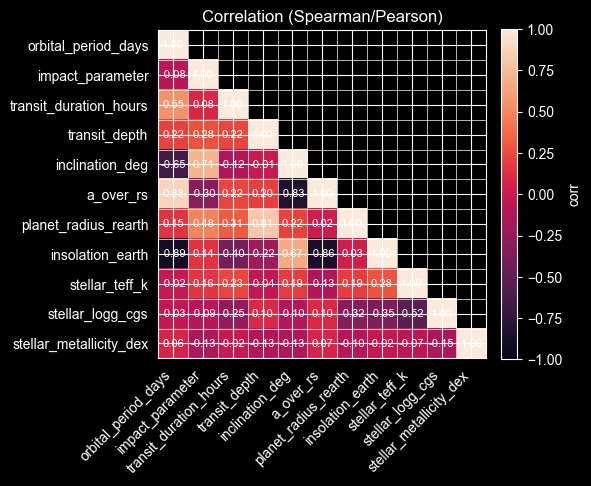

In [22]:
corr_koi = koi_test.corr(method="spearman")
plot_corr_heatmap(corr_koi, annotate=True)

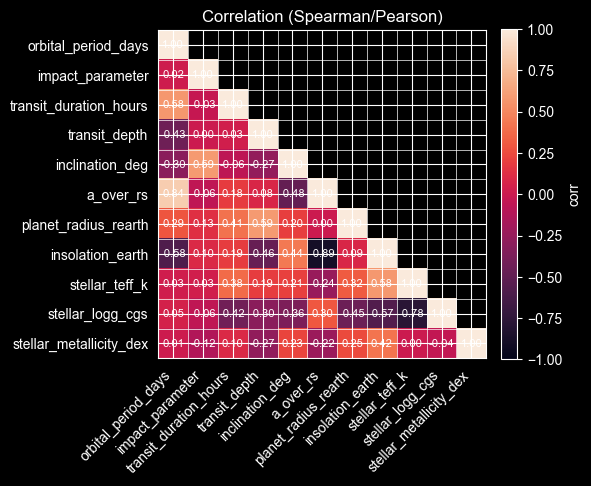

In [23]:
corr_k2p = k2p.corr(method="spearman")
plot_corr_heatmap(corr_k2p, annotate=True)

### Summary
In the next step, in the file `pipeline.ipynb`, a pipeline for data preprocessing will be created. It will:
* drop columns: ["eccentricity", 'semi_major_axis_au', 'equilibrium_temp_k', 'radius_ratio_rp_rs', 'stellar_radius_rsun', 'stellar_mass_msun']
* apply log transformation to features: ["insolation_earth", "transit_depth", "a_over_rs", "planet_radius_rearth", "orbital_period_days", "transit_duration_hours"] (right-skewed) and ["inclination_deg"] (left-skewed)
* perform further preprocessing for machine learning, described later in the file